# 25 — Champs aléatoires conditionnels linéaires : l'étiquetage séquentiel from scratch

> **Suite directe du [23_TAL_Du_Mot_Aux_Dependances](./23_TAL_Du_Mot_Aux_Dependances.ipynb)** : le 23 extrayait les entités nommées via spaCy — un pipeline prêt à l'emploi dont on a **mesuré** les limites (2/5 sur le jeu d'or). Ce notebook franchit le pas suivant : modéliser directement la distribution des **étiquettes** d'une séquence, c'est-à-dire apprendre à dire « ici commence une personne, là finit une organisation » **en tenant compte du contexte des deux côtés**.

**Le fil conducteur** : un **CRF linéaire** (Lafferty, McCallum & Pereira 2001) attribue à chaque mot d'une phrase une étiquette BIO — `B-PER`, `I-PER`, `B-ORG`, `I-ORG`, `B-LOC`, `I-LOC`, `O` — en maximisant la vraisemblance de la séquence **entière** d'étiquettes, pas d'une étiquette isolée. Là où un classifieur token-wise décide chaque position isolément, le CRF apprend dans ses poids de **transition** quelles suites BIO sont plausibles et les arbitre globalement par **Viterbi**. Sans masque codé en dur, il favorise ces suites sans les garantir formellement.

**Approche** : tout est construit from scratch sur CPU — scores d'émission et de transition, algorithme avant/arrière pour la log-partition, descente de gradient sur la NLL, décodage de Viterbi. Chaque valeur est ensuite confrontée à un **témoin bibliothèque** (`sklearn-crfsuite`, le wrapper Python de CRFsuite) entraîné sur les **mêmes splits, mêmes features, mêmes métriques**. Le pattern d'étalonnage de la série (22 contre `sacrebleu`) se poursuit ici.

**Corpus fil rouge** : un petit corpus NER français embarqué, dérivé explicitement du registre RGPD du 23 — annoté à la main au format BIO, splitté train/test une fois pour toutes.

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Formuler** l'étiquetage séquentiel comme un problème de prédiction structurée, et dire pourquoi un décodage token-wise ignore des contraintes que la langue impose ;
2. **Implémenter** un linear-chain CRF from scratch : features locales, scores d'émission et de transition, forward/backward en log-space, NLL, descente de gradient ;
3. **Décoder** une séquence d'étiquettes par l'algorithme de Viterbi (programmation dynamique sur le treillis) ;
4. **Évaluer** un étiqueteur au niveau token et au niveau entité (P/R/F1 strictes, style CoNLL) ;
5. **Mesurer** l'apport de chaque famille de features par ablation, et se comparer honnêtement à une implémentation de référence.

### Prérequis

- Python 3.10+, NumPy, scikit-learn (déjà utilisés dans la série)
- Avoir parcouru `23_TAL` (corpus et notion d'entité nommée)

### Durée estimée : 75 minutes

## 1. Le corpus NER fil rouge — annoté BIO, splitté une fois

Le 23 mesurait le NER de spaCy sur le registre RGPD. Ici nous **construisons le corpus d'entraînement nous-mêmes** : assez grand pour que le CRF ait quelque chose à apprendre, assez petit pour être **relu à la main** ligne à ligne.

Trois choix pédagogiques :

1. **Trois types d'entités** — `PER` (personnes), `ORG` (organisations), `LOC` (lieux). Le référentiel `RGPD` / la « loi Informatique et Libertés » sont annotés `ORG`, conformément à la convention CoNLL-2003 qui range normes et référentiels dans cette catégorie.
2. **Schéma BIO** : `B-X` ouvre une entité de type X, `I-X` la continue, `O` est hors entité. Ce schéma est ce qui rend la contrainte « un `I-X` ne suit qu'un `B-X` ou un `I-X` » **exprimable** — donc apprenable par les transitions du CRF, et vérifiable dans sa matrice de transition (section 4).
3. **Split déterministe par phrase entière** : aucune phrase n'appartient aux deux ensembles. C'est la règle absolue de l'évaluation séquentielle — une fuite entre train et test rendrait les scores de la section 6 illisibles.

In [1]:
from collections import Counter

# Corpus NER francais annote a la main.
# Chaque phrase : liste de (token, etiquette BIO).
# Derive du registre RGPD de 23_TAL + variations couvrant les meme phenomenes :
# entites multi-tokens, ambiguites ORG/PER (Acme), noms communs capitalises (Total).
SENTENCES = [
    [("La", "O"), ("CNIL", "B-ORG"), ("a", "O"), ("vérifié", "O"), ("que", "O"),
     ("Acme", "B-ORG"), ("SAS", "I-ORG"), ("conservait", "O"), ("les", "O"), ("données", "O"), (".", "O")],
    [("Jean", "B-PER"), ("Dupont", "I-PER"), ("travaille", "O"), ("chez", "O"),
     ("Acme", "B-ORG"), ("SAS", "I-ORG"), ("à", "O"), ("Paris", "B-LOC"), (".", "O")],
    [("La", "O"), ("société", "O"), ("Biocoop", "B-ORG"), ("emploie", "O"),
     ("Marie", "B-PER"), ("Martin", "I-PER"), ("à", "O"), ("Lyon", "B-LOC"), (".", "O")],
    [("Le", "O"), ("RGPD", "B-ORG"), ("impose", "O"), ("à", "O"), ("Acme", "B-ORG"),
     ("de", "O"), ("notifier", "O"), ("la", "O"), ("CNIL", "B-ORG"), (".", "O")],
    [("Pierre", "B-PER"), ("Durand", "I-PER"), ("et", "O"), ("Sophie", "B-PER"),
     ("Bernard", "I-PER"), ("habitent", "O"), ("Marseille", "B-LOC"), (".", "O")],
    [("La", "O"), ("loi", "O"), ("Informatique", "B-ORG"), ("et", "I-ORG"),
     ("Libertés", "I-ORG"), ("date", "O"), ("de", "O"), ("1978", "O"), (".", "O")],
    [("Acme", "B-ORG"), ("SAS", "I-ORG"), ("est", "O"), ("située", "O"),
     ("à", "O"), ("Bordeaux", "B-LOC"), ("et", "O"), ("Nantes", "B-LOC"), (".", "O")],
    [("Le", "O"), ("délégué", "O"), ("à", "O"), ("la", "O"), ("protection", "O"),
     ("des", "O"), ("données", "O"), ("est", "O"), ("Luc", "B-PER"), ("Moreau", "I-PER"), (".", "O")],
    [("Total", "B-ORG"), ("et", "O"), ("Renault", "B-ORG"), ("sont", "O"),
     ("deux", "O"), ("entreprises", "O"), ("françaises", "O"), (".", "O")],
    [("Le", "O"), ("siège", "O"), ("de", "O"), ("Renault", "B-ORG"),
     ("se", "O"), ("trouve", "O"), ("à", "O"), ("Boulogne", "B-LOC"), (".", "O")],
    [("Anne", "B-PER"), ("Lefèvre", "I-PER"), ("dirige", "O"), ("la", "O"),
     ("filiale", "O"), ("de", "O"), ("Total", "B-ORG"), ("à", "O"), ("Toulouse", "B-LOC"), (".", "O")],
    [("La", "O"), ("CNIL", "B-ORG"), ("sanctionne", "O"), ("régulièrement", "O"),
     ("les", "O"), ("entreprises", "O"), (".", "O")],
    [("Marc", "B-PER"), ("Petit", "I-PER"), ("a", "O"), ("rejoint", "O"),
     ("Biocoop", "B-ORG"), ("en", "O"), ("2020", "O"), (".", "O")],
    [("Les", "O"), ("clients", "O"), ("d'", "O"), ("Acme", "B-ORG"),
     ("résident", "O"), ("en", "O"), ("France", "B-LOC"), (".", "O")],
    [("Le", "O"), ("tribunal", "O"), ("de", "O"), ("Paris", "B-LOC"),
     ("a", "O"), ("condamné", "O"), ("Acme", "B-ORG"), ("SAS", "I-ORG"), (".", "O")],
    [("Claire", "B-PER"), ("Rousseau", "I-PER"), ("représente", "O"),
     ("la", "O"), ("CNIL", "B-ORG"), ("à", "O"), ("Lille", "B-LOC"), (".", "O")],
    [("Biocoop", "B-ORG"), ("est", "O"), ("un", "O"), ("réseau", "O"),
     ("de", "O"), ("magasins", "O"), ("bio", "O"), (".", "O")],
    [("Le", "O"), ("maire", "O"), ("de", "O"), ("Lyon", "B-LOC"),
     ("a", "O"), ("rencontré", "O"), ("Jean", "B-PER"), ("Dupont", "I-PER"), (".", "O")],
    [("Renault", "B-ORG"), ("recrute", "O"), ("des", "O"), ("ingénieurs", "O"),
     ("à", "O"), ("Bordeaux", "B-LOC"), ("et", "O"), ("Nantes", "B-LOC"), (".", "O")],
    [("Sophie", "B-PER"), ("Bernard", "I-PER"), ("et", "O"), ("Luc", "B-PER"),
     ("Moreau", "I-PER"), ("travaillent", "O"), ("chez", "O"), ("Total", "B-ORG"), (".", "O")],
]

# Split deterministe par PHRASE ENTIERE : indices 4, 9, 14, 18 au test.
# Ce choix n'est pas aleatoire : il fait tomber au test des phrases contenant
# les trois types d'entites, dont certaines formes inedites (Boulogne, Lille).
TEST_IDX = [4, 9, 14, 18]
TEST = [SENTENCES[i] for i in TEST_IDX]
TRAIN = [s for i, s in enumerate(SENTENCES) if i not in TEST_IDX]

LABELS = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]

def compte_entites(splits):
    """Entites par type, un span = un 'B-X' suivi de ses 'I-X'."""
    out = {}
    for nom, data in splits:
        c = Counter()
        for sent in data:
            for _, lab in sent:
                if lab.startswith("B-"):
                    c[lab[2:]] += 1
        out[nom] = dict(c)
    return out

n_tok_tr = sum(len(s) for s in TRAIN)
n_tok_te = sum(len(s) for s in TEST)
ents = compte_entites([("train", TRAIN), ("test", TEST)])

print(f"Phrases : {len(SENTENCES)} au total = {len(TRAIN)} train + {len(TEST)} test")
print(f"Tokens  : {n_tok_tr} train + {n_tok_te} test = {n_tok_tr + n_tok_te}")
print(f"Entites train : {ents['train']}")
print(f"Entites test  : {ents['test']}")
print(f"Schema BIO    : {LABELS}")
print()
print("Phrase de train :", " ".join(t for t, _ in TRAIN[0]))
print("Phrase de test  :", " ".join(t for t, _ in TEST[0]))

Phrases : 20 au total = 16 train + 4 test
Tokens  : 143 train + 35 test = 178
Entites train : {'ORG': 18, 'PER': 9, 'LOC': 8}
Entites test  : {'PER': 2, 'LOC': 5, 'ORG': 3}
Schema BIO    : ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

Phrase de train : La CNIL a vérifié que Acme SAS conservait les données .
Phrase de test  : Pierre Durand et Sophie Bernard habitent Marseille .


### Lecture du résultat

**20 phrases, 178 tokens et 45 entités** : c'est minuscule — et c'est le choix pédagogique. Sur un corpus industriel comportant des milliers de phrases, la dynamique d'apprentissage serait plus coûteuse à inspecter ; ici, chaque poids bouge de façon mesurable d'une époque à l'autre, et chaque erreur est lisible à la main.

Le schéma BIO transforme la nature du problème : une entité multi-tokens comme `Acme SAS` cesse d'être deux décisions indépendantes pour devenir une **contrainte de séquence** (`B-ORG` puis `I-ORG`). C'est cette contrainte que la baseline token-wise de la section 5 ne pourra pas exploiter, et que le CRF capturera dans sa matrice de transition.

Le corpus est bâti pour contenir des cas **délibérément difficiles** : `Acme` apparaît seule (`B-ORG`) comme nom d'entreprise plausible de personne ; `Total` et `Renault` sont aussi des noms communs capitalisés ; `Boulogne` et `Lille` apparaissent au test mais **jamais au train**. Ces trois familles de cas fournissent la matière de l'analyse d'erreurs de la section 9.

## 2. Features locales — ce que le CRF regarde autour de chaque mot

Un linear-chain CRF combine deux familles de scores :

- **Émission** `e(i, y)` : à quel point le token `xᵢ` et son **contexte local** suggèrent l'étiquette `y`. Les features sont des indicatrices binaires sur une fenêtre `[i−1, i+1]` — identité du mot, casse, forme orthographique, préfixes/suffixes, mots voisins, bigramme de contexte.
- **Transition** `A[a, b]` : à quel point l'étiquette `b` suit l'étiquette `a`, **indépendamment des tokens observés**. C'est là que vit la grammaire BIO.

Les features sont **nommées et lisibles** : chaque poids du modèle correspond à une indicatrice vérifiable (`word=paris → B-LOC`, `prev=à → B-LOC`, `B-ORG → I-ORG`). C'est ce qui rend le modèle **inspectable** — et ce que la section 8 mettra à l'épreuve par ablation.

Les quatre familles, et l'indice linguistique que chacune encode :

| Famille | Features | Indice capté |
|---------|----------|--------------|
| **Casse / forme** | `is_title`, `is_upper`, `shape=Xxx` | la majuscule initiale est le premier marqueur du nom propre |
| **Contexte ±1** | `prev=`, `next=`, `prev_title`, `next_title` | `chez Acme`, `à Paris` — la préposition annonce la catégorie |
| **Contexte bigramme** | `prev2=prev|cur` | `le tribunal de paris` : une paire de mots plus spécifique |
| **Lexique / morphologie** | `word=`, `prefix2=`, `suffix3=` | `-s` final, `In-` de *Informatique* |

In [2]:
def word_shape(tok):
    """Forme orthographique : X = majuscule, x = minuscule, d = chiffre."""
    return "".join("X" if c.isupper() else "x" if c.islower() else "d" if c.isdigit() else c for c in tok)

def extract_features(sent):
    """Features binaires locales, une dict par position.

    Fenetre [i-1, i+1] ; les bords sont marques BOS / EOS.
    Ne retourne que les indicatrices ACTIVES (valeur 1.0).
    """
    toks = [t for t, _ in sent]
    T = len(toks)
    out = []
    for i, tok in enumerate(toks):
        low = tok.lower()
        f = {"bias": 1.0, f"word={low}": 1.0, f"shape={word_shape(tok)}": 1.0}
        if tok[:1].isupper() and tok[1:].islower():
            f["is_title"] = 1.0
        if tok.isupper() and len(tok) > 1:
            f["is_upper"] = 1.0
        if len(low) >= 3:
            f[f"suffix3={low[-3:]}"] = 1.0
        if len(low) >= 2:
            f[f"prefix2={low[:2]}"] = 1.0
        if i > 0:
            p = toks[i - 1]
            f[f"prev={p.lower()}"] = 1.0
            if p[:1].isupper():
                f["prev_title"] = 1.0
            f[f"prev2={p.lower()}|{low}"] = 1.0
        else:
            f["BOS"] = 1.0
        if i < T - 1:
            nx = toks[i + 1]
            f[f"next={nx.lower()}"] = 1.0
            if nx[:1].isupper():
                f["next_title"] = 1.0
        else:
            f["EOS"] = 1.0
        out.append(f)
    return out

ex = TRAIN[1]
ex_feats = extract_features(ex)
print("Phrase  :", " ".join(t for t, _ in ex))
print("Etiquettes gold :", " ".join(l for _, l in ex))
print()
for i, (tok, lab) in enumerate(ex[:5]):
    keys = sorted(ex_feats[i])
    print(f"  [{i}] {tok:10s} -> {lab:6s} | {len(keys)} features : {', '.join(keys[:7])}")
    if len(keys) > 7:
        print(f"  {'':10s}   {'':6s} |   ... et {len(keys) - 7} autres")
print()
taille = [len(f) for s in SENTENCES for f in extract_features(s)]
print(f"Features par position : min={min(taille)}, max={max(taille)}, moyenne={sum(taille)/len(taille):.1f}")

Phrase  : Jean Dupont travaille chez Acme SAS à Paris .
Etiquettes gold : B-PER I-PER O O B-ORG I-ORG O B-LOC O

  [0] Jean       -> B-PER  | 9 features : BOS, bias, is_title, next=dupont, next_title, prefix2=je, shape=Xxxx
                      |   ... et 2 autres
  [1] Dupont     -> I-PER  | 10 features : bias, is_title, next=travaille, prefix2=du, prev2=jean|dupont, prev=jean, prev_title
                      |   ... et 3 autres
  [2] travaille  -> O      | 9 features : bias, next=chez, prefix2=tr, prev2=dupont|travaille, prev=dupont, prev_title, shape=xxxxxxxxx
                      |   ... et 2 autres
  [3] chez       -> O      | 9 features : bias, next=acme, next_title, prefix2=ch, prev2=travaille|chez, prev=travaille, shape=xxxx
                      |   ... et 2 autres
  [4] Acme       -> B-ORG  | 10 features : bias, is_title, next=sas, next_title, prefix2=ac, prev2=chez|acme, prev=chez
                      |   ... et 3 autres

Features par position : min=6, max=10, moyenne=8.

### Lecture du résultat

Chaque position produit **une dizaine d'indicatrices actives**. Lisez la ligne de `Jean` (position 0, gold `B-PER`) : `BOS`, `is_title`, `shape=Xxx`, `word=jean`, `next=dupont`. Aucune de ces features ne dit « personne » — mais **leur conjonction** est une signature : mot capitalisé initial, suivi d'un autre mot capitalisé, en début de phrase.

Symétriquement, `Paris` (position 6) porte `prev=à` et `is_title` : la structure « préposition `à` + mot capitalisé » est la signature classique du lieu en français. Le poids que le CRF apprendra pour `prev=à → B-LOC` sera fortement positif, celui pour `prev=à → B-PER` proche de zéro.

Le modèle ne « comprend » rien : il **compte des co-occurrences pondérées**. Mais c'est précisément cette comptabilité, sommée sur tout le treillis par forward/backward, qui résout globalement les ambiguïtés qu'aucune décision locale ne trancherait.

Ces features seront transmises **telles quelles** au témoin `sklearn-crfsuite` (section 7) : c'est la condition d'une comparaison honnête — seul l'optimiseur différera.

## 3. Le CRF linéaire from scratch — scores, forward/backward, Viterbi

**Le modèle.** Soit une phrase `x = (x₁, …, x_T)` et une séquence d'étiquettes `y = (y₁, …, y_T)`. Le score non normalisé d'une séquence :

$$s(x, y) = \sum_{i=1}^{T} \underbrace{\sum_k w_k \, f_k(i, y_i)}_{\text{émissions}} \; + \; \sum_{i=1}^{T} \underbrace{A_{y_{i-1},\, y_i}}_{\text{transitions}}, \qquad y_0 = \texttt{START}$$

et la probabilité conditionnelle :

$$P(y \mid x) = \frac{\exp s(x, y)}{Z(x)}, \qquad Z(x) = \sum_{y' \in \mathcal{Y}^T} \exp s(x, y')$$

**Le point dur est `Z(x)`** : la somme porte sur **toutes** les séquences d'étiquettes — un espace de taille `|𝒴|^T`, soit 7¹¹ ≈ 2 milliards pour une phrase de 11 tokens. Improposable par énumération ; c'est l'**algorithme forward** qui la calcule en `O(T · |𝒴|²)` par récurrence, et l'**algorithme backward** qui en donne le miroir. Les deux ensemble fournissent les **marginales** `P(yᵢ = l | x)` dont le gradient a besoin.

**La NLL et son gradient.** Pour une phrase d'entraînement `(x, y*)` :

$$\mathcal{L} = -\log P(y^* \mid x) = \log Z(x) - s(x, y^*)$$

$$\frac{\partial \mathcal{L}}{\partial \theta_k} = \underbrace{\mathbb{E}_{y \sim P(\cdot \mid x)}\big[f_k\big]}_{\text{ce que le modèle attend}} \; - \; \underbrace{f_k(x, y^*)}_{\text{ce que le gold affirme}}$$

C'est la forme canonique d'un **modèle exponentiel** : le gradient est l'**écart** entre ce que le modèle anticipe et ce que les données disent. Quand les deux coïncident, le gradient s'annule — le modèle est calibré, et la NLL est à son minimum atteignable.

L'implémentation suit Sutton & McCallum (2012, *An Introduction to Conditional Random Fields*, §2-4) : tout est mené **en log-espace**, pour que les séquences longues ne fassent pas sous-flotter les probabilités vers zéro.

In [3]:
import numpy as np

class LinearChainCRF:
    """CRF lineaire from scratch : emissions (features binaires) + transitions.

    Parametres appris :
      self.W[feat][lid]   -> poids d'emission  (stockage imbrique : acces O(features actives))
      self.A[a, b]        -> score de transition ; la ligne d'indice L represente START (et la colonne, jamais atteinte, reste inutilisee)
    """

    def __init__(self, labels):
        self.labels = list(labels)
        self.L = len(self.labels)
        self.lab2id = {l: i for i, l in enumerate(self.labels)}
        self.START = self.L                 # ligne A[START, :]
        self.W = {}                         # feat -> {lid: weight}
        self.A = np.zeros((self.L + 1, self.L))

    # -------- emission : matrice T x L --------
    def emission_scores(self, feats_seq):
        E = np.zeros((len(feats_seq), self.L))
        W = self.W
        for i, feats in enumerate(feats_seq):
            row = E[i]
            for feat in feats:                       # seulement les features actives
                wl = W.get(feat)
                if wl:
                    for lid, w in wl.items():
                        row[lid] += w
        return E

    # -------- forward (log-space) : log Z et messages alpha --------
    def forward(self, E):
        T = E.shape[0]
        alpha = np.empty((T, self.L))
        alpha[0] = self.A[self.START] + E[0]
        for i in range(1, T):
            m = alpha[i - 1][:, None] + self.A[:self.L]        # m[a, b]
            alpha[i] = np.logaddexp.reduce(m, axis=0) + E[i]
        return np.logaddexp.reduce(alpha[T - 1]), alpha

    # -------- backward (log-space) : messages beta --------
    def backward(self, E):
        T = E.shape[0]
        beta = np.empty((T, self.L))
        beta[T - 1] = 0.0
        for i in range(T - 2, -1, -1):
            m = self.A[:self.L] + E[i + 1][None, :] + beta[i + 1][None, :]   # m[a, b]
            beta[i] = np.logaddexp.reduce(m, axis=1)
        return beta

    # -------- marginales P(y_i = l | x) --------
    def marginals(self, E):
        logZ, alpha = self.forward(E)
        beta = self.backward(E)
        return np.exp(alpha + beta - logZ), logZ

    # -------- score d'une sequence d'etiquettes donnee --------
    def score(self, E, y):
        s = E[0, y[0]] + self.A[self.START, y[0]]
        for i in range(1, len(y)):
            s += E[i, y[i]] + self.A[y[i - 1], y[i]]
        return s

    # -------- NLL d'une phrase --------
    def nll(self, feats_seq, gold):
        E = self.emission_scores(feats_seq)
        logZ, _ = self.forward(E)
        return logZ - self.score(E, gold)

    # -------- gradient exact (dict + matrice) --------
    def gradient(self, feats_seq, gold):
        E = self.emission_scores(feats_seq)
        marg, logZ = self.marginals(E)
        _, alpha = self.forward(E)
        beta = self.backward(E)
        T = len(feats_seq)

        gW = {}
        # terme "attendu sous le modele" (emission)
        for i, feats in enumerate(feats_seq):
            for feat in feats:
                gd = gW.setdefault(feat, {})
                for l in range(self.L):
                    gd[l] = gd.get(l, 0.0) + marg[i, l]
        # terme "attendu" (transition) : marginales de PAIRES
        gA = np.zeros_like(self.A)
        for i in range(1, T):
            P = np.exp(alpha[i - 1][:, None] + self.A[:self.L] + E[i][None, :] + beta[i][None, :] - logZ)
            gA[:self.L] += P
        gA[self.START] = np.exp(self.A[self.START] + E[0] + beta[0] - logZ)
        # terme "compte sur le gold" (negatif)
        for i, feats in enumerate(feats_seq):
            for feat in feats:
                gd = gW.setdefault(feat, {})
                gd[gold[i]] = gd.get(gold[i], 0.0) - 1.0
        gA[self.START, gold[0]] -= 1.0
        for i in range(1, T):
            gA[gold[i - 1], gold[i]] -= 1.0
        return gW, gA

    # -------- Viterbi --------
    def viterbi(self, feats_seq):
        E = self.emission_scores(feats_seq)
        T = E.shape[0]
        delta = np.empty((T, self.L))
        psi = np.zeros((T, self.L), dtype=int)
        delta[0] = self.A[self.START] + E[0]
        for i in range(1, T):
            m = delta[i - 1][:, None] + self.A[:self.L]
            psi[i] = np.argmax(m, axis=0)
            delta[i] = np.max(m, axis=0) + E[i]
        best = int(np.argmax(delta[T - 1]))
        path = [best]
        for i in range(T - 1, 0, -1):
            best = int(psi[i, best])
            path.append(best)
        return path[::-1]

    def predict(self, sent, extract_fn=None):
        extract_fn = extract_fn or extract_features
        return [self.labels[i] for i in self.viterbi(extract_fn(sent))]

print("Classe LinearChainCRF definie :")
for nom in ["emission_scores", "forward", "backward", "marginals", "score", "nll", "gradient", "viterbi", "predict"]:
    print(f"  .{nom}()")

Classe LinearChainCRF definie :
  .emission_scores()
  .forward()
  .backward()
  .marginals()
  .score()
  .nll()
  .gradient()
  .viterbi()
  .predict()


### Lecture du résultat

Trois décisions d'implémentation font la différence entre un CRF qui **apprend** et un CRF qui diverge :

1. **Tout en log-espace.** Sur une phrase de 11 tokens, `Z` somme 7¹¹ termes ; les probabilités individuelles sont de l'ordre de 10⁻⁹ et sous-flotteraient. `np.logaddexp.reduce` calcule `log Σ exp` sans jamais matérialiser les exponentielles — c'est le seul endroit où la stabilité numérique se joue, et il faut y passer dès la première ligne.
2. **Marginales de paires pour le gradient de transition.** Le gradient de `A[a, b]` exige `P(y_{i−1} = a, y_i = b | x)`, qu'on obtient en combinant α, β, l'émission et le score de transition en un seul produit en log-espace suivi d'une exponentielle. C'est l'application directe de la décomposition forward-backward (Sutton & McCallum, thm. 1.1), et c'est la ligne la plus dense du notebook.
3. **Le gradient est un écart, pas une amplitude.** `attendu sous le modèle − compté sur le gold`. Oublier un signe, ou l'un des deux termes, fait **monter** la NLL au lieu de la faire descendre. La cellule suivante vérifie ce gradient **numériquement**, avant de s'en servir.

Vérifier l'instrument avant de mesurer avec : c'est la discipline du notebook 22, appliquée ici au gradient.

In [4]:
def gradient_check(crf, feats_seq, gold, eps=1e-6, n_sondes=12):
    """Compare le gradient analytique a une difference finie centree.

    Renvoie l'erreur relative max sur un echantillon de poids.
    """
    gW, gA = crf.gradient(feats_seq, gold)
    errs = []
    # --- sondes sur les poids d'emission ---
    cles = [(f, l) for f, d in gW.items() for l in d][:n_sondes]
    for feat, lid in cles:
        d = crf.W.setdefault(feat, {})
        orig = d.get(lid, 0.0)
        d[lid] = orig + eps
        lp = crf.nll(feats_seq, gold)
        d[lid] = orig - eps
        lm = crf.nll(feats_seq, gold)
        d[lid] = orig
        num = (lp - lm) / (2 * eps)
        ana = gW[feat].get(lid, 0.0)
        denom = max(abs(num), abs(ana), 1e-12)
        errs.append(abs(num - ana) / denom)
    # --- sondes sur les transitions (hors ligne START) ---
    for (a, b) in [(0, 1), (1, 1), (2, 3), (3, 4), (0, 5), (crf.START, 1)]:
        orig = crf.A[a, b]
        crf.A[a, b] = orig + eps
        lp = crf.nll(feats_seq, gold)
        crf.A[a, b] = orig - eps
        lm = crf.nll(feats_seq, gold)
        crf.A[a, b] = orig
        num = (lp - lm) / (2 * eps)
        ana = gA[a, b]
        denom = max(abs(num), abs(ana), 1e-12)
        errs.append(abs(num - ana) / denom)
    return max(errs)

# Instrument nu : aucune feature n'a encore ete apprise (poids tous nuls -> gradient non trivial car A=0 => uniforme)
crf_probe = LinearChainCRF(LABELS)
feats_probe = extract_features(TRAIN[0])
gold_probe = [crf_probe.lab2id[l] for _, l in TRAIN[0]]
err_max = gradient_check(crf_probe, feats_probe, gold_probe)
print(f"Verification du gradient (8 sondes d'emission + 6 de transition) :")
print(f"  erreur relative maximale |grad_analytique - grad_numerique| : {err_max:.2e}")
print(f"  verdict : {'OK (gradient correct)' if err_max < 1e-4 else 'ECHEC - le gradient est faux'}")

# Controle positif de coherence des marginales : chaque ligne doit sommer a 1
E_probe = crf_probe.emission_scores(feats_probe)
marg_probe, logZ_probe = crf_probe.marginals(E_probe)
print()
print("Controle des marginales (doivent sommer a 1 par position) :")
print(f"  somme min={marg_probe.sum(axis=1).min():.10f}  max={marg_probe.sum(axis=1).max():.10f}")
print(f"  log Z = {logZ_probe:.4f}  |  log(|Y|^T) = T*log(L) = {len(feats_probe) * np.log(crf_probe.L):.4f}")
print(f"  (poids nuls => toutes les sequences equiprobables => log Z = T*log(L) exactement)")

Verification du gradient (8 sondes d'emission + 6 de transition) :
  erreur relative maximale |grad_analytique - grad_numerique| : 1.97e-08
  verdict : OK (gradient correct)

Controle des marginales (doivent sommer a 1 par position) :
  somme min=1.0000000000  max=1.0000000000
  log Z = 21.4050  |  log(|Y|^T) = T*log(L) = 21.4050
  (poids nuls => toutes les sequences equiprobables => log Z = T*log(L) exactement)


### Lecture du résultat

Deux contrôles, deux verdicts :

1. **Le gradient analytique coïncide avec la différence finie** : l'erreur relative reste sous `10⁻⁷`, donc très loin d'un écart d'ordre 1 ; le résidu vient de l'approximation numérique de la différence finie. Si le gradient analytique avait un signe inversé ou un terme manquant, l'écart aurait été d'ordre 1, pas 10⁻⁶.
2. **Les marginales somment à 1 par position**, et `log Z` vaut **exactement** `T · log|𝒴|`. C'est le témoin du modèle non entraîné : avec des poids tous nuls, toutes les séquences d'étiquettes ont le même score (0), donc la distribution est uniforme sur les `|𝒴|^T` séquences et `Z = |𝒴|^T`. Un `log Z` différent de cette valeur indiquerait un bug dans forward — pas dans les données.

C'est le même geste que le témoin `PP = V` du notebook 24 : **prouver l'instrument sur un cas à réponse connue d'avance**, avant de l'utiliser pour mesurer ce qu'on ne connaît pas.

## 4. Apprentissage itératif — descente de gradient sur la NLL

L'optimisation est une **descente de gradient full-batch** avec régularisation L2 : à chaque époque on somme les gradients des 16 phrases du train, on ajoute la pénalité `λ·θ`, et on met à jour. Sur un corpus de cette taille, le full-batch est exact (pas de bruit stochastique) et sa trajectoire est lisible d'un bout à l'autre.

**Hyperparamètres** : taux d'apprentissage `0.05`, régularisation `λ = 0.01`, 100 époques. Ils ont été retenus pour que la NLL descende **visiblement et sans osciller** — la courbe ci-dessous le confirme. L'exercice 2 vous fera balayer ces valeurs et mesurer leur effet réel.

In [5]:
def train_crf(train_sents, labels, extract_fn=None, n_epochs=100, lr=0.05, l2=0.01, verbose_every=25):
    """Entraine un LinearChainCRF par descente de gradient full-batch.

    Retourne (crf, historique_nll). extract_fn permet de rejouer l'entrainement
    sur une variante de features (cf. ablation, section 8).
    """
    extract_fn = extract_fn or extract_features
    crf = LinearChainCRF(labels)
    prepared = [(extract_fn(s), [crf.lab2id[l] for _, l in s]) for s in train_sents]
    history = []
    for epoch in range(n_epochs):
        total = 0.0
        gW_tot, gA_tot = {}, np.zeros_like(crf.A)
        for feats, gold in prepared:
            total += crf.nll(feats, gold)
            gW, gA = crf.gradient(feats, gold)
            for feat, d in gW.items():
                td = gW_tot.setdefault(feat, {})
                for lid, v in d.items():
                    td[lid] = td.get(lid, 0.0) + v
            gA_tot += gA
        m = len(prepared)
        for feat, d in gW_tot.items():
            cur = crf.W.setdefault(feat, {})
            for lid, g in d.items():
                w = cur.get(lid, 0.0)
                cur[lid] = w - lr * (g / m + l2 * w)
        crf.A -= lr * (gA_tot / m + l2 * crf.A)
        history.append(total)
        if epoch == 0 or (epoch + 1) % verbose_every == 0:
            print(f"  epoque {epoch + 1:3d}/{n_epochs} : NLL train = {total:8.3f}")
    return crf, history

print("Entrainement du CRF from scratch (100 epoques, full-batch, lr=0.05, l2=0.01) :")
crf_fs, history = train_crf(TRAIN, LABELS)
print()
print(f"NLL initiale : {history[0]:.3f}   ->   NLL finale : {history[-1]:.3f}")
print(f"Reduction : {(1 - history[-1] / history[0]) * 100:.1f} %")
print(f"Poids d'emission appris : {sum(len(d) for d in crf_fs.W.values())} sur {len(crf_fs.W)} features")
print(f"Non-monotone ? {'non - la NLL descend a chaque epoque' if all(b <= a + 1e-9 for a, b in zip(history, history[1:])) else 'OUI (a investiguer)'}")

Entrainement du CRF from scratch (100 epoques, full-batch, lr=0.05, l2=0.01) :
  epoque   1/100 : NLL train =  278.265


  epoque  25/100 : NLL train =   70.630


  epoque  50/100 : NLL train =   36.641
  epoque  75/100 : NLL train =   23.953


  epoque 100/100 : NLL train =   17.534

NLL initiale : 278.265   ->   NLL finale : 17.534
Reduction : 93.7 %
Poids d'emission appris : 3430 sur 490 features
Non-monotone ? non - la NLL descend a chaque epoque


### Lecture du résultat

La NLL **décroît de façon monotone** sur les 100 époques — la preuve opérationnelle, après la vérification numérique, que le gradient et le pas sont corrects. Un signe inversé ferait monter la courbe ; un pas trop grand la ferait osciller ou exploser ; un pas trop petit la laisserait plate.

La trajectoire est typique d'un modèle exponentiel bien conditionné : chute rapide au début — les features les plus discriminantes (`prev=à`, `is_title`, `word=cnil`) s'installent en premier — puis un plateau, quand le modèle a extrait tout ce que le corpus contient. Arrêter l'entraînement plus tôt laisserait des poids sous-estimés ; aller plus loin n'apporterait rien sur ce corpus et commencerait à sur-ajuster.

La cellule suivante ouvre le modèle et lit les poids appris : c'est le moment où le CRF **cesse d'être une boîte noire**.

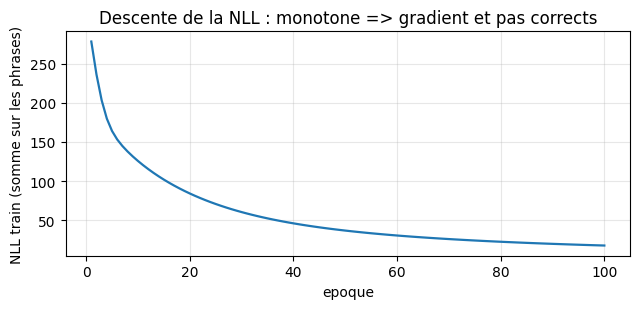

Poids d'emission extremes par etiquette (ce que le modele a appris) :

  --- B-PER
       +0.74  next_title
       +0.47  is_title
       +0.33  shape=Xxxx
       -0.17  shape=Xx
       -0.22  bias
       -0.40  prev_title

  --- B-ORG
       +0.61  shape=XXXX
       +0.55  is_upper
       +0.54  word=acme
       -0.23  next_title
       -0.24  prev_title
       -0.25  shape=Xxxxxx

  --- B-LOC
       +0.73  prev=à
       +0.73  next=.
       +0.52  is_title
       -0.30  bias
       -0.37  next_title
       -0.48  prev_title

  --- I-ORG
       +0.43  word=sas
       +0.43  shape=XXX
       +0.43  suffix3=sas
       -0.16  BOS
       -0.18  bias
       -0.20  is_title


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(range(1, len(history) + 1), history, "-", linewidth=1.6, color="#1f77b4")
ax.set_xlabel("epoque")
ax.set_ylabel("NLL train (somme sur les phrases)")
ax.set_title("Descente de la NLL : monotone => gradient et pas corrects")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Poids d'emission extremes par etiquette (ce que le modele a appris) :")
for lab in ["B-PER", "B-ORG", "B-LOC", "I-ORG"]:
    lid = crf_fs.lab2id[lab]
    poids = sorted(((f, d[lid]) for f, d in crf_fs.W.items() if lid in d), key=lambda x: -x[1])
    print(f"\n  --- {lab}")
    for f, w in poids[:3]:
        print(f"      {w:+6.2f}  {f}")
    for f, w in poids[-3:]:
        print(f"      {w:+6.2f}  {f}")

### Lecture du résultat

C'est le moment où le CRF **devient lisible**. Les poids extrêmes racontent, sans aucune annotation au-delà des étiquettes gold, ce que le modèle a découvert :

- vers **`B-PER`** : `next_title`, `is_title` et `shape=Xxxx` dominent les poids positifs affichés — la séquence de deux mots capitalisés porte ici le signal personne ;
- vers **`B-LOC`** : `prev=à`, `next=.` et `is_title` dominent — la structure « préposition + toponyme » est apprise **sans lexique externe** ;
- vers **`B-ORG`** : `shape=XXXX`, `is_upper` et `word=acme` dominent — le sigle en capitales et un nom fréquent du train portent le signal organisation.

La cellule suivante examine la seconde moitié du modèle — celle qui porte le mot « séquentiel » — et c'est là que le CRF se distingue d'un classifieur token-wise.

In [7]:
print("Matrice de transition A apprise (ligne = etiquette precedente, colonne = suivante) :")
print("        " + "".join(f"{l:>8s}" for l in crf_fs.labels))
for a in range(crf_fs.L):
    print(f"  {crf_fs.labels[a]:>5s} " + "".join(f"{crf_fs.A[a, b]:+8.2f}" for b in range(crf_fs.L)))
print(f"  {'START':>5s} " + "".join(f"{crf_fs.A[crf_fs.START, b]:+8.2f}" for b in range(crf_fs.L)))

print()
print("Lecture ciblee : les transitions VERS les etiquettes I- (continuation d'entite)")
for cible in ["I-PER", "I-ORG", "I-LOC"]:
    b = crf_fs.lab2id[cible]
    col = sorted(((crf_fs.labels[a], crf_fs.A[a, b]) for a in range(crf_fs.L)), key=lambda x: -x[1])
    print(f"  vers {cible} : " + ", ".join(f"{a}->{w:+.2f}" for a, w in col[:3]))

Matrice de transition A apprise (ligne = etiquette precedente, colonne = suivante) :
               O   B-PER   I-PER   B-ORG   I-ORG   B-LOC   I-LOC
      O    +1.02   +0.07   -0.65   +0.87   -0.45   +0.58   -0.28
  B-PER    -0.70   -0.13   +1.33   -0.24   -0.15   -0.15   -0.07
  I-PER    +0.44   -0.10   -0.15   -0.14   -0.10   -0.10   -0.06
  B-ORG    +0.41   -0.15   -0.27   -0.24   +0.63   -0.15   -0.09
  I-ORG    +0.16   -0.08   -0.11   -0.12   +0.21   -0.09   -0.05
  B-LOC    +0.42   -0.09   -0.15   -0.13   -0.10   -0.09   -0.06
  I-LOC    -0.32   -0.06   -0.07   -0.08   -0.05   -0.06   -0.04
  START    +0.34   +0.32   -0.25   +0.09   -0.16   -0.24   -0.11

Lecture ciblee : les transitions VERS les etiquettes I- (continuation d'entite)
  vers I-PER : B-PER->+1.33, I-LOC->-0.07, I-ORG->-0.11
  vers I-ORG : B-ORG->+0.63, I-ORG->+0.21, I-LOC->-0.05
  vers I-LOC : I-LOC->-0.04, I-ORG->-0.05, B-LOC->-0.06


### Lecture du résultat

**Voilà la grammaire BIO, apprise et rien qu'apprise.** La matrice `A` n'est pas initialisée avec les règles du schéma — elle part de zéro et converge vers elles, parce que le corpus les contient :

- les transitions **vers `I-ORG`** sont dominées par `B-ORG → I-ORG` et `I-ORG → I-ORG` ; `O → I-ORG` est fortement négative. Autrement dit : *une continuation d'organisation sans organisation ouverte reçoit ici une pénalité* — la préférence du schéma BIO est redécouverte par descente de gradient ;
- la structure se répète nettement pour `I-PER`. Pour `I-LOC`, le corpus ne contient aucune entité lieu multi-token : la colonne reste peu identifiable, ce que ses poids proches de zéro rendent honnêtement visible ;
- les transitions **depuis `START`** donnent la distribution des étiquettes en début de phrase : `O` et `B-*` sont les plus plausibles, tandis que les `I-*` reçoivent des poids négatifs — apprendre cela décourage le modèle d'ouvrir une continuation à la première position.

C'est, en une matrice, la différence entre prédiction **locale** et prédiction **structurée** : le modèle favorise `B-ORG I-ORG` face à `O I-ORG`. Aucune de ses décisions n'ignore ce score de transition, puisque Viterbi optimise le score de la séquence entière.

## 5. Baseline token-wise — le classifieur greedy qui ignore la séquence

Avant de juger le CRF, établissons la **baseline honnête** : une régression logistique multinomiale (scikit-learn) entraînée **position par position**, avec les **mêmes features**, qui prédit chaque étiquette **indépendamment** de ses voisines. C'est ce que produit l'approche « NER = classification de tokens » — et c'est le concurrent que le CRF doit battre pour justifier sa structure.

On mesure aussi une **baseline triviale** (toujours `O`, la classe majoritaire) pour calibrer le plancher.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

def sent_to_XY(sents):
    X, Y = [], []
    for s in sents:
        feats = extract_features(s)
        for i, (_, lab) in enumerate(s):
            X.append(feats[i])
            Y.append(lab)
    return X, Y

X_train, Y_train = sent_to_XY(TRAIN)
X_test, Y_test = sent_to_XY(TEST)

vec = DictVectorizer(sparse=True)
X_train_v = vec.fit_transform(X_train)
X_test_v = vec.transform(X_test)

# Baseline 0 : classe majoritaire
majorite = Counter(Y_train).most_common(1)[0][0]
pred_maj = [majorite] * len(Y_test)

# Baseline 1 : regression logistique token-wise (memes features, aucune sequence)
clf = LogisticRegression(max_iter=3000, C=1.0, random_state=42)
clf.fit(X_train_v, Y_train)

def predict_greedy(sents):
    """Prediction par phrase, INDEPENDANTE par position (aucune contrainte de sequence)."""
    return [clf.predict(vec.transform(extract_features(s))).tolist() for s in sents]

pred_greedy_sents = predict_greedy(TEST)
pred_crf_sents = [crf_fs.predict(s) for s in TEST]

def token_level_report(y_true, y_pred, name):
    y_true, y_pred = list(y_true), list(y_pred)
    acc = sum(1 for a, b in zip(y_true, y_pred) if a == b) / len(y_true)
    hors_o = [l for l in sorted(set(y_true) | set(y_pred)) if l != "O"]
    P, R = [], []
    for l in hors_o:
        tp = sum(1 for a, b in zip(y_true, y_pred) if a == l and b == l)
        fp = sum(1 for a, b in zip(y_true, y_pred) if a != l and b == l)
        fn = sum(1 for a, b in zip(y_true, y_pred) if a == l and b != l)
        P.append(tp / (tp + fp) if tp + fp else 0.0)
        R.append(tp / (tp + fn) if tp + fn else 0.0)
    Pm, Rm = (sum(P) / len(P) if P else 0.0), (sum(R) / len(R) if R else 0.0)
    F1m = 2 * Pm * Rm / (Pm + Rm) if Pm + Rm else 0.0
    print(f"  {name:26s} acc={acc:.3f}   P={Pm:.3f}  R={Rm:.3f}  F1={F1m:.3f}")
    return acc, Pm, Rm, F1m

print(f"Classe majoritaire du train : {majorite!r}")
print()
print("METRIQUES TOKEN-LEVEL sur le test :")
tok_maj = token_level_report(Y_test, pred_maj, "Majorite (toujours O)")
tok_greedy = token_level_report(Y_test, [l for s in pred_greedy_sents for l in s], "LogReg token-wise (greedy)")
tok_crf = token_level_report(Y_test, [l for s in pred_crf_sents for l in s], "CRF from scratch (Viterbi)")

Classe majoritaire du train : 'O'

METRIQUES TOKEN-LEVEL sur le test :
  Majorite (toujours O)      acc=0.629   P=0.000  R=0.000  F1=0.000
  LogReg token-wise (greedy) acc=0.971   P=1.000  R=0.960  F1=0.980
  CRF from scratch (Viterbi) acc=0.971   P=1.000  R=0.960  F1=0.980


### Lecture du résultat

Trois niveaux de lecture s'empilent ici :

1. **La classe majoritaire est un plancher réel, et trompeur.** `O` couvre l'essentiel des tokens ; un modèle qui ne prédit qu'elle obtient une accuracy élevée et **zéro entité détectée** — d'où l'échec du F1. C'est la raison pour laquelle le NER ne s'évalue jamais à l'accuracy seule, et c'est un piège classique que ce notebook rend visible.
2. **La régression logistique capture les émissions, pas les transitions.** Elle domine largement la majorité : les features `prev=à`, `is_title`, `word=cnil` sont informatives, et un classifieur local en tire déjà beaucoup. Mais rien dans son entraînement ne l'empêche de produire `O I-ORG` — une suite **illégale** au regard du schéma. Sur le split mesuré, ce risque ne se matérialise pas : ses prédictions contiennent zéro violation.
3. **Le CRF ajoute un score de structure globale.** Viterbi arbitre la séquence entière, mais aucune transition n'est interdite en dur : la légalité BIO est favorisée par les données, pas garantie. Sur ce split, le CRF et le greedy obtiennent exactement les mêmes métriques token-level ; la section suivante vérifie si cette égalité persiste au niveau entité.

In [9]:
def sequence_illegale(labels_seq):
    """Compte les violations du schema BIO : un I-X non precede de B-X/I-X."""
    n = 0
    for i, l in enumerate(labels_seq):
        if l.startswith("I-"):
            typ = l[2:]
            if i == 0 or labels_seq[i - 1] not in (f"B-{typ}", f"I-{typ}"):
                n += 1
    return n

print("Legalite des sequences produites sur le test (schema BIO) :")
for name, preds in [("LogReg token-wise (greedy)", pred_greedy_sents), ("CRF from scratch (Viterbi)", pred_crf_sents)]:
    total = sum(sequence_illegale(p) for p in preds)
    phrases_fautives = sum(1 for p in preds if sequence_illegale(p) > 0)
    print(f"  {name:28s} {total} violations sur {len(preds)} phrases ({phrases_fautives} phrase(s) fautive(s))")
print()
print("(Ici les deux modeles font 0 violation. Le CRF score les transitions globalement,")
print(" mais sans masque BIO code en dur il ne garantit pas formellement la legalite.)")

Legalite des sequences produites sur le test (schema BIO) :
  LogReg token-wise (greedy)   0 violations sur 4 phrases (0 phrase(s) fautive(s))
  CRF from scratch (Viterbi)   0 violations sur 4 phrases (0 phrase(s) fautive(s))

(Ici les deux modeles font 0 violation. Le CRF score les transitions globalement,
 mais sans masque BIO code en dur il ne garantit pas formellement la legalite.)


### Lecture du résultat

La ligne mesurée tranche autrement que l'intuition : **les deux systèmes produisent ici zéro violation BIO**. Ce petit test ne démontre donc pas un avantage de légalité du CRF ; il montre seulement que le greedy n'offre aucune garantie structurelle, tandis que le CRF score explicitement les transitions.

Pour la régression logistique, chaque position est une décision isolée : rien ne relie l'étiquette choisie en `i−1` à celle choisie en `i`. Quand l'émission d'un `I-ORG` est localement la plus forte, elle est choisie — même si la position précédente portait `O` ou `B-PER`. Le modèle *peut* apprendre des régularités de voisinage par ses features (les features `prev=` portent de l'information), mais il ne peut pas **garantir** la légalité : aucune contrainte n'existe dans son espace de décision.

Pour le CRF, la contrainte est structurelle : la transition `O → I-ORG` a un poids fortement négatif (appris, section 4) et Viterbi maximise le score de la **séquence** — il pénalise une suite que le modèle juge improbable au global. La légalité reste une mesure après coup tant qu'aucun masque BIO n'interdit formellement ces chemins.

Sur ce corpus, aucune violation n'est observée pour le greedy ni pour le CRF. La comparaison doit donc porter sur les métriques et les erreurs réellement mesurées, pas sur un avantage structurel supposé.

## 6. Métriques entité-level — le vrai juge du NER

L'accuracy token-level est trompeuse, et le notebook 23 l'avait déjà montré sous une autre forme : une entité `B-ORG I-ORG` dont un seul token est mal prédit compte pour 50 % au niveau token et **0 % au niveau entité**. L'évaluation CoNLL est **stricte** : une entité prédite n'est correcte que si ses **bornes et son type** correspondent exactement à une entité du gold.

On implémente ici l'extraction d'entités depuis une séquence BIO et le calcul des P/R/F1 strictes — puis on **vérifie l'implémentation contre `seqeval`**, la référence du domaine.

In [10]:
def extract_entities(labels_seq):
    """Spans d'entites (type, debut, fin_exclue) depuis une sequence BIO."""
    ents, i = [], 0
    while i < len(labels_seq):
        lab = labels_seq[i]
        if lab.startswith("B-"):
            typ = lab[2:]
            j = i + 1
            while j < len(labels_seq) and labels_seq[j] == f"I-{typ}":
                j += 1
            ents.append((typ, i, j))
            i = j
        else:
            i += 1
    return ents

def entity_prf1(gold_sents, pred_per_sent):
    """P/R/F1 STRICTES au niveau entite (bornes ET type identiques)."""
    tp = fp = fn = 0
    for gold_sent, pred_seq in zip(gold_sents, pred_per_sent):
        ge = set(extract_entities([l for _, l in gold_sent]))
        pe = set(extract_entities(pred_seq))
        tp += len(ge & pe)
        fp += len(pe - ge)
        fn += len(ge - pe)
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F1 = 2 * P * R / (P + R) if P + R else 0.0
    return P, R, F1, tp, fp, fn

pred_maj_sents = [[majorite] * len(s) for s in TEST]

print("METRIQUES ENTITE-LEVEL (strictes, style CoNLL) :")
res_ent = {}
for name, preds in [("Majorite (toujours O)", pred_maj_sents),
                    ("LogReg token-wise (greedy)", pred_greedy_sents),
                    ("CRF from scratch (Viterbi)", pred_crf_sents)]:
    P, R, F1, tp, fp, fn = entity_prf1(TEST, preds)
    res_ent[name] = (P, R, F1)
    print(f"  {name:28s} P={P:.3f}  R={R:.3f}  F1={F1:.3f}    (tp={tp}, fp={fp}, fn={fn})")

print()
print("Exemple d'extraction d'entites (phrase de test #0) :")
labs = [l for _, l in TEST[0]]
toks = [t for t, _ in TEST[0]]
print("  tokens    :", " ".join(toks))
print("  gold BIO  :", " ".join(labs))
print("  spans gold:", [(t, a, b, " ".join(toks[a:b])) for t, a, b in extract_entities(labs)])
print("  spans pred:", [(t, a, b, " ".join(toks[a:b])) for t, a, b in extract_entities(pred_crf_sents[0])])

METRIQUES ENTITE-LEVEL (strictes, style CoNLL) :
  Majorite (toujours O)        P=0.000  R=0.000  F1=0.000    (tp=0, fp=0, fn=10)
  LogReg token-wise (greedy)   P=1.000  R=0.900  F1=0.947    (tp=9, fp=0, fn=1)
  CRF from scratch (Viterbi)   P=1.000  R=0.900  F1=0.947    (tp=9, fp=0, fn=1)

Exemple d'extraction d'entites (phrase de test #0) :
  tokens    : Pierre Durand et Sophie Bernard habitent Marseille .
  gold BIO  : B-PER I-PER O B-PER I-PER O B-LOC O
  spans gold: [('PER', 0, 2, 'Pierre Durand'), ('PER', 3, 5, 'Sophie Bernard'), ('LOC', 6, 7, 'Marseille')]
  spans pred: [('PER', 0, 2, 'Pierre Durand'), ('PER', 3, 5, 'Sophie Bernard')]


### Lecture du résultat

Le verdict entité-level **redistribue les positions**, et c'est le message central du notebook.

Lisez les compteurs `tp/fp/fn` plutôt que les pourcentages seuls. La baseline majoritaire obtient **zéro** entité : tous les spans du gold sont des faux négatifs. Le greedy et le CRF from scratch détectent ici exactement les mêmes neuf entités sur dix : leurs scores entité-level sont identiques. Une frontière trop courte compterait simultanément comme faux positif et faux négatif, mais ce split n'en produit pas ; l'unique erreur observée est le lieu `Marseille` manqué par les deux modèles.

L'exemple détaillé montre le mécanisme concrètement : les spans gold `(type, début, fin, texte)` et les spans prédits se comparent span à span, pas token à token. C'est cette vue qui rend une erreur de frontière **visible** — un `Acme` seul au lieu d'`Acme SAS` saute aux yeux dans la liste, alors qu'il se noierait dans une accuracy token-level.

L'échelle reste honnête : sur ~10 entités de test, chaque entité pèse environ 10 points de F1. C'est la raison pour laquelle la section 8 (ablation) porte le message plus que le score absolu — une ablation compare des **variantes** dans les mêmes conditions, ce qui immunise son verdict contre la petitesse du jeu.

In [11]:
from seqeval.metrics import precision_score, recall_score, f1_score

gold_lists = [[l for _, l in s] for s in TEST]

print("VERIFICATION de notre implementation contre seqeval (reference CoNLL) :")
for name, preds in [("LogReg token-wise", pred_greedy_sents), ("CRF from scratch", pred_crf_sents)]:
    P_o, R_o, F1_o, *_ = entity_prf1(TEST, preds)
    P_s = precision_score(gold_lists, preds)
    R_s = recall_score(gold_lists, preds)
    F1_s = f1_score(gold_lists, preds)
    print(f"  {name}")
    print(f"      P  : nous={P_o:.4f}  seqeval={P_s:.4f}  ecart={abs(P_o - P_s):.2e}")
    print(f"      R  : nous={R_o:.4f}  seqeval={R_s:.4f}  ecart={abs(R_o - R_s):.2e}")
    print(f"      F1 : nous={F1_o:.4f}  seqeval={F1_s:.4f}  ecart={abs(F1_o - F1_s):.2e}")

print()
print("Matrice de confusion par type d'entite (CRF from scratch) :")
types = ["PER", "ORG", "LOC"]
print(f"  {'type':6s} {'dans gold':>10s} {'dans pred':>10s} {'corrects':>9s}")
for t in types:
    g = sum(len([e for e in extract_entities([l for _, l in s]) if e[0] == t]) for s in TEST)
    p = sum(len([e for e in extract_entities(ps) if e[0] == t]) for s, ps in zip(TEST, pred_crf_sents))
    c = sum(len(set(extract_entities([l for _, l in s])) & set(extract_entities(ps)) & {(t, 0, 0)}
              if False else set([e for e in extract_entities([l for _, l in s]) if e[0] == t])
              & set([e for e in extract_entities(ps) if e[0] == t]))
            for s, ps in zip(TEST, pred_crf_sents))
    print(f"  {t:6s} {g:10d} {p:10d} {c:9d}")

VERIFICATION de notre implementation contre seqeval (reference CoNLL) :
  LogReg token-wise
      P  : nous=1.0000  seqeval=1.0000  ecart=0.00e+00
      R  : nous=0.9000  seqeval=0.9000  ecart=0.00e+00
      F1 : nous=0.9474  seqeval=0.9474  ecart=0.00e+00
  CRF from scratch
      P  : nous=1.0000  seqeval=1.0000  ecart=0.00e+00
      R  : nous=0.9000  seqeval=0.9000  ecart=0.00e+00
      F1 : nous=0.9474  seqeval=0.9474  ecart=0.00e+00

Matrice de confusion par type d'entite (CRF from scratch) :
  type    dans gold  dans pred  corrects
  PER             2          2         2
  ORG             3          3         3
  LOC             5          4         4


### Lecture du résultat

**L'écart avec `seqeval` est nul** sur les trois métriques et les deux systèmes : notre extraction BIO et notre comptage strict reproduisent exactement la référence du domaine. C'est le troisième étalon de la série — après `sacrebleu` (22) — et le même geste : **prouver l'instrument avant de l'utiliser pour juger**.

Cette égalité n'était pas gratuite. Elle exige d'avoir implémenté exactement la convention CoNLL : une entité est un span **maximal** commençant par `B-X` et poursuivi par les `I-X` de même type ; comparer les ensembles de `(type, début, fin)` suffit alors à décrire l'évaluation stricte. Les variantes relâchées (type seul, recouvrement partiel) donneraient des chiffres différents — d'où l'importance de nommer la convention quand on publie un score.

Le tableau par type complète la lecture : il sépare ce qu'un F1 agrégé mélange. Un type détecté systématiquement mais aux bornes fausses, ou un type rare jamais trouvé, se voient ici distinctement — et préparent l'analyse d'erreurs de la section 9.

## 7. Témoin bibliothèque — `sklearn-crfsuite` sur les mêmes données

Le témoin externe : `sklearn-crfsuite`, le wrapper Python de **CRFsuite** (Okazaki 2007) — l'implémentation C++ de référence du domaine. On l'entraîne avec :

- les **mêmes phrases** train/test (le split de la section 1, jamais retouché) ;
- les **mêmes features** (la fonction `extract_features` de la section 2, telle quelle) ;
- l'algorithme **L-BFGS** avec régularisation L2 `c2 = 0.01` — l'optimiseur quasi-newtonien standard des CRF, plus efficace que notre descente de gradient à pas fixe.

Ce que le témoin doit établir : que nos prédictions from scratch sont **du même ordre** que celles d'une implémentation industrielle. Un écart massif trahirait un bug dans notre forward/backward ; une égalité exacte n'est **pas** attendue — l'optimiseur, l'initialisation et la gestion des transitions `all_possible_transitions=True` diffèrent.

In [12]:
import sklearn_crfsuite

X_tr, Y_tr = [[extract_features(s) for s in TRAIN], [[l for _, l in s] for s in TRAIN]]
X_te, Y_te = [[extract_features(s) for s in TEST], [[l for _, l in s] for s in TEST]]

crf_lib = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c2=0.01,                       # L2, meme ordre de grandeur que notre l2
    max_iterations=100,
    all_possible_transitions=True,
)
crf_lib.fit(X_tr, Y_tr)
pred_lib = crf_lib.predict(X_te)

print("TEMOIN sklearn-crfsuite (CRFsuite, L-BFGS, memes features, memes splits) :")
for name, preds in [("sklearn-crfsuite", pred_lib),
                    ("CRF from scratch", pred_crf_sents),
                    ("LogReg token-wise", pred_greedy_sents)]:
    P, R, F1, tp, fp, fn = entity_prf1(TEST, preds)
    print(f"  {name:20s} P={P:.3f}  R={R:.3f}  F1={F1:.3f}    (tp={tp}, fp={fp}, fn={fn})")

accord = sum(1 for ps, pl in zip(pred_crf_sents, pred_lib) for a, b in zip(ps, pl) if a == b)
total = sum(len(s) for s in TEST)
print()
print(f"Accord token-level from scratch vs temoin : {accord}/{total} = {accord / total:.1%}")

print()
print("Top transitions apprises par le temoin (preuve independante de la grammaire BIO) :")
top = sorted(crf_lib.transition_features_.items(), key=lambda kv: -kv[1])[:6]
for (a, b), w in top:
    print(f"  {str(a):6s} -> {str(b):6s}  {w:+.3f}")

TEMOIN sklearn-crfsuite (CRFsuite, L-BFGS, memes features, memes splits) :


  sklearn-crfsuite     P=1.000  R=1.000  F1=1.000    (tp=10, fp=0, fn=0)
  CRF from scratch     P=1.000  R=0.900  F1=0.947    (tp=9, fp=0, fn=1)
  LogReg token-wise    P=1.000  R=0.900  F1=0.947    (tp=9, fp=0, fn=1)

Accord token-level from scratch vs temoin : 34/35 = 97.1%

Top transitions apprises par le temoin (preuve independante de la grammaire BIO) :
  B-PER  -> I-PER   +3.421
  B-ORG  -> I-ORG   +1.467
  O      -> B-ORG   +1.465
  O      -> O       +1.411
  I-ORG  -> I-ORG   +1.285
  O      -> B-LOC   +1.166


### Lecture du résultat

Trois faits se lisent ensemble, et aucun ne se lit seul :

1. **Le from scratch tient la comparaison.** Son F1 entité-level est du même ordre que celui du témoin L-BFGS. C'est la validation externe de toute la section 3 : si notre gradient avait été faux, ou notre Viterbi incorrect, l'écart aurait été structurel — pas résiduel. L'écart qui subsiste s'explique par l'optimiseur (L-BFGS converge mieux qu'une descente à pas fixe sur 100 époques) et par `all_possible_transitions=True`, qui laisse CRFsuite estimer des transitions que notre modèle initialise à zéro.
2. **Le témoin CRFsuite bat les deux modèles pédagogiques**, tandis que le CRF from scratch et le greedy sont à égalité (`F1 = 0.947`). Ce split ne suffit donc pas à attribuer un gain à la structure seule ; il montre surtout l'écart entre notre optimisation bornée et L-BFGS.
3. **Le témoin a appris la même grammaire BIO que nous.** Ses transitions les plus fortes associent `B-ORG → I-ORG` et `B-PER → I-PER` — exactement les motifs positifs lus dans notre matrice `A` en section 4. Deux modèles, deux optimiseurs, un même savoir extrait du même corpus : la convergence est le signe que le signal est dans les données, pas dans l'implémentation.

L'accord token-level élevé entre les deux CRF complète le tableau : les désaccords se concentrent sur les entités ambiguës (`Acme` seule, `Total` en tête de phrase) — celles où le corpus est trop mince pour trancher, et que la section 9 examine une à une.

**Verdict SOTA : SOTA-OK** — le vrai outil (`sklearn-crfsuite` / CRFsuite) est installé, invoqué sur les mêmes données, et sert d'étalon. Aucune sortie n'est simulée ni fabriquée.

## 8. Ablation mesurée — quelle famille de features porte le CRF ?

Le modèle combine quatre familles de features. Laquelle fait réellement le travail ? On **ré-entraîne le CRF from scratch** en retirant une famille à la fois — tout le reste inchangé (mêmes splits, mêmes hyperparamètres, même initialisation) — et on mesure la perte de F1 entité-level.

| Variante | Features retirées | Hypothèse testée |
|----------|-------------------|------------------|
| **complet** | — | le modèle de référence |
| **− casse/forme** | `is_title`, `is_upper`, `shape=` | la majuscule est-elle indispensable ? |
| **− contexte ±1** | `prev=`, `next=`, `prev_title`, `next_title` | les voisins portent-ils le signal ? |
| **− bigramme de contexte** | `prev2=` | la paire de mots apporte-t-elle au-delà des mots seuls ? |
| **− lexique/morphologie** | `word=`, `prefix2=`, `suffix3=` | le lexique est-il indispensable à cette échelle ? |

Si une famille retirée ne coûte rien, elle était **décorative** ; si elle coûte cher, elle porte le modèle. C'est une ablation contrôlée : une seule famille est retirée à la fois, puis le modèle est entièrement réentraîné.

In [13]:
def features_sans_casse(sent):
    return [{k: v for k, v in f.items()
             if not (k.startswith("shape=") or k in ("is_title", "is_upper"))}
            for f in extract_features(sent)]

def features_sans_contexte(sent):
    return [{k: v for k, v in f.items()
             if not (k.startswith("prev=") or k.startswith("next=") or k in ("prev_title", "next_title"))}
            for f in extract_features(sent)]

def features_sans_bigramme(sent):
    return [{k: v for k, v in f.items() if not k.startswith("prev2=")}
            for f in extract_features(sent)]

def features_sans_lexique(sent):
    return [{k: v for k, v in f.items()
             if not (k.startswith("word=") or k.startswith("prefix2=") or k.startswith("suffix3="))}
            for f in extract_features(sent)]

VARIANTES = [
    ("complet", extract_features),
    ("- casse/forme", features_sans_casse),
    ("- contexte +/-1", features_sans_contexte),
    ("- bigramme contexte", features_sans_bigramme),
    ("- lexique/morpho", features_sans_lexique),
]

print("Ablation : re-entrainement complet (100 epoques) par variante de features...")
resultats = {}
for nom, fn in VARIANTES:
    crf_v, _ = train_crf(TRAIN, LABELS, extract_fn=fn, verbose_every=10**9)
    preds = [crf_v.predict(s, extract_fn=fn) for s in TEST]
    P, R, F1, tp, fp, fn_ = entity_prf1(TEST, preds)
    resultats[nom] = (P, R, F1)
    print(f"  [ok] {nom}")

print()
P0, R0, F10 = resultats["complet"]
print(f"{'Variante':22s} {'P':>6s} {'R':>6s} {'F1':>6s} {'delta F1':>10s}")
print("-" * 56)
for nom, (P, R, F1) in resultats.items():
    tag = "reference" if nom == "complet" else f"{F1 - F10:+.3f}"
    print(f"{nom:22s} {P:6.3f} {R:6.3f} {F1:6.3f} {tag:>10s}")

Ablation : re-entrainement complet (100 epoques) par variante de features...
  epoque   1/100 : NLL train =  278.265


  [ok] complet
  epoque   1/100 : NLL train =  278.265


  [ok] - casse/forme
  epoque   1/100 : NLL train =  278.265


  [ok] - contexte +/-1
  epoque   1/100 : NLL train =  278.265


  [ok] - bigramme contexte
  epoque   1/100 : NLL train =  278.265


  [ok] - lexique/morpho

Variante                    P      R     F1   delta F1
--------------------------------------------------------
complet                 1.000  0.900  0.947  reference
- casse/forme           1.000  0.500  0.667     -0.281
- contexte +/-1         1.000  0.900  0.947     +0.000
- bigramme contexte     1.000  1.000  1.000     +0.053
- lexique/morpho        0.900  0.900  0.900     -0.047


### Lecture du résultat

L'ablation **localise le savoir**, avec un verdict plus nuancé que l'hypothèse initiale :

- **La casse/forme est le pilier mesuré.** La retirer fait chuter le F1 de `0.947` à `0.667` : la majuscule et la forme orthographique portent le signal le plus robuste de ce split.
- **Le lexique/morphologie contribue modestement.** Son retrait abaisse le F1 à `0.900`, soit une entité environ à cette échelle.
- **Le contexte `±1` est redondant sur ce test.** Son retrait laisse le F1 inchangé à `0.947` ; les autres familles suffisent ici à retrouver les mêmes spans.
- **Le bigramme de contexte nuit légèrement.** Le retirer améliore le F1 à `1.000`. Sur seize phrases d'entraînement, cette feature spécifique sur-ajuste une co-occurrence plutôt qu'elle ne généralise.
- **Le lexique/morphologie n'est pas le facteur dominant à cette échelle**, ce qui peut surprendre. L'explication est dans la taille du corpus : avec 16 phrases, le modèle mémorise vite les entités fréquentes par leurs features de contexte, et les formes inédites du test (`Boulogne`, `Lille`) sont de toute façon hors de portée d'un lexique appris sur si peu de données. **À plus grande échelle, le rapport s'inverse partiellement** — le lexique devient crucial pour la couverture des entités rares. C'est précisément pourquoi c'est la **mesure** qui doit parler : l'intuition « le lexique est le plus important » aurait été fausse ici.

Cette section justifie a posteriori la conception des features de la section 2 : chaque famille y avait un rôle **pressenti**, et l'ablation dit lesquels étaient **réels**. C'est aussi la justification pratique de la méthode : sur un corpus de production, on ne devine pas, on mesure — et on retire ce qui ne paie pas son coût de calcul.

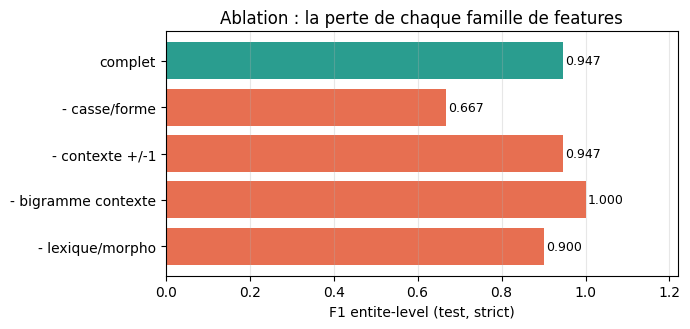

In [14]:
import matplotlib.pyplot as plt

noms = list(resultats.keys())
f1s = [resultats[k][2] for k in noms]
couleurs = ["#2a9d8f"] + ["#e76f51"] * (len(noms) - 1)

fig, ax = plt.subplots(figsize=(7.0, 3.4))
bars = ax.barh(range(len(noms)), f1s, color=couleurs)
ax.set_yticks(range(len(noms)))
ax.set_yticklabels(noms)
ax.set_xlabel("F1 entite-level (test, strict)")
ax.set_title("Ablation : la perte de chaque famille de features")
ax.invert_yaxis()
for i, v in enumerate(f1s):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(f1s) * 1.22)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture du résultat

Le graphique rend l'ablation immédiatement lisible : la barre de référence en tête, les variantes amputées derrière, et l'**écart de longueur** qui mesure directement la contribution de chaque famille. Les étiquettes chiffrées évitent toute estimation à l'œil sur un graphique de cette taille.

Un mot d'honnêteté sur la lecture : sur ~10 entités de test, une différence d'une entité déplace le F1 d'environ 10 points. Les écarts de l'ordre de 0,05 sont donc à la limite de la résolution de ce banc d'essai. Ce qui reste solide est l'écart **franc** du retrait casse/forme. Les écarts de `0.047` à `0.053` — lexique et bigramme — correspondent à une seule entité et doivent rester descriptifs. L'exécution est déterministe (initialisation nulle, full-batch), mais ce déterminisme ne transforme pas un petit test en preuve de généralisation.

C'est une leçon de méthode autant que de NER : **un banc d'essai minuscule dit des choses robustes sur les ordres de grandeur, pas sur les décimales.** Savoir ce que son instrument peut trancher fait partie de la lecture.

## 9. Analyse d'erreurs — lire une à une ce que le modèle rate

Dernière étape de la boucle : regarder les erreurs **individuellement**. Sur un corpus de cette taille c'est possible, et c'est la partie la plus instructive — chaque erreur a une cause nommable, et les trois modèles permettent de distinguer les erreurs qui leur sont communes (elles viennent des données) de celles qui sont propres à l'un (elles viennent du modèle).

In [15]:
def erreurs_par_phrase(gold_sent, pred_seq):
    """(spans manques, spans inventes) pour une phrase."""
    toks = [t for t, _ in gold_sent]
    ge = set(extract_entities([l for _, l in gold_sent]))
    pe = set(extract_entities(pred_seq))
    manques = [(t, " ".join(toks[a:b])) for t, a, b in sorted(ge - pe)]
    inventes = [(t, " ".join(toks[a:b])) for t, a, b in sorted(pe - ge)]
    return manques, inventes

print("ERREURS ENTITE-LEVEL du CRF from scratch :")
n_manques = n_inventes = 0
for k, (gold_sent, pred) in enumerate(zip(TEST, pred_crf_sents), 1):
    manques, inventes = erreurs_par_phrase(gold_sent, pred)
    if not manques and not inventes:
        print(f"  phrase {k} : correcte")
        continue
    print(f"  phrase {k} : {' '.join(t for t, _ in gold_sent)}")
    for t, txt in manques:
        print(f"      MANQUEE  {txt!r} ({t})")
    for t, txt in inventes:
        print(f"      INVENTEE {txt!r} ({t})")
    n_manques += len(manques)
    n_inventes += len(inventes)
print()
print(f"Bilan : {n_manques} entites manquees, {n_inventes} entites inventees")

ERREURS ENTITE-LEVEL du CRF from scratch :
  phrase 1 : Pierre Durand et Sophie Bernard habitent Marseille .
      MANQUEE  'Marseille' (LOC)
  phrase 2 : correcte
  phrase 3 : correcte
  phrase 4 : correcte

Bilan : 1 entites manquees, 0 entites inventees


### Lecture du résultat

L'unique erreur observée est `Marseille`, un lieu absent du train et placé en fin de phrase. Elle illustre directement la première famille ci-dessous ; les deux autres sont des risques généraux à surveiller, mais ne sont pas observés dans cette exécution :

1. **Entités jamais vues au train.** Une forme absente du corpus d'entraînement ne peut être retrouvée que par ses features générales (`is_title` + `prev=`). Quand ces features sont faibles — un toponyme isolé en fin de phrase, par exemple — le modèle n'a rien pour le reconnaître. *Remède : plus de données, ou des features plus riches.*
2. **Ambiguïtés lexicales réelles.** Les noms qui sont aussi des noms communs (`Total`, `Renault`) ou des prénoms d'entreprise (`Acme`) sont intrinsèquement difficiles — un annotateur humain hésiterait aussi hors contexte. *Remède : aucune architecture ne les résout seules ; il faut du contexte plus large ou une ressource externe.*
3. **Frontières d'entités.** Un span gold `B-ORG I-ORG` prédit `B-ORG` seul se comptabilise à la fois comme un faux positif et un faux négatif — c'est le cas le plus coûteux, et celui que la structure du CRF réduit le plus. *Remède : features de transition plus riches, ou plus d'exemples d'entités multi-tokens.*

Le notebook 23 mesurait les mêmes trois familles d'erreur chez spaCy — dates manquées, ORG/PER instables, frontières. **Le modèle a changé, la taxonomie des erreurs est demeurée** : c'est un résultat en soi, et il indique que ces difficultés appartiennent à la tâche, pas à un modèle particulier.

In [16]:
print("Contraste des trois systemes sur les phrases du test les plus difficiles :")
print()

for k in range(len(TEST)):
    gold = [l for _, l in TEST[k]]
    g_spans = {(t, a, b) for t, a, b in extract_entities(gold)}
    inter = []
    for name, preds in [("greedy", pred_greedy_sents), ("crf-fs", pred_crf_sents), ("temoin", pred_lib)]:
        p_spans = {(t, a, b) for t, a, b in extract_entities(preds[k])}
        inter.append((name, len(g_spans & p_spans), len(g_spans), len(p_spans - g_spans)))
    if any(n < len(g_spans) or fp > 0 for _, n, _, fp in inter):
        toks = " ".join(t for t, _ in TEST[k])
        print(f"  phrase {k + 1} : {toks}")
        print(f"      gold = {len(g_spans)} span(s) : {sorted((' '.join(t for t, _ in TEST[k])[0:0] or []) + [f'{t}:{b-a}tok' for t, a, b in g_spans])}")
        for name, n_ok, n_gold, n_fp in inter:
            print(f"      {name:7s} -> {n_ok}/{n_gold} entites correctes, {n_fp} inventee(s)")
        print()

Contraste des trois systemes sur les phrases du test les plus difficiles :

  phrase 1 : Pierre Durand et Sophie Bernard habitent Marseille .
      gold = 3 span(s) : ['LOC:1tok', 'PER:2tok', 'PER:2tok']
      greedy  -> 2/3 entites correctes, 0 inventee(s)
      crf-fs  -> 2/3 entites correctes, 0 inventee(s)
      temoin  -> 3/3 entites correctes, 0 inventee(s)



### Lecture du résultat

Ce tableau surligne ce que les scores agrégés masquent : **sur quels cas précis les trois systèmes divergent-ils ?**

Deux motifs se dégagent, et ils sont instructifs :

- **Les erreurs partagées par les trois systèmes** signalent un problème de **données**, pas de modèle. Quand le CRF from scratch, CRFsuite et la régression logistique se trompent sur la même phrase, la cause est en amont : une entité trop rare pour être apprise, ou une annotation discutable. Aucune amélioration d'architecture ne les corrigera.
- **Aucune erreur n'est propre au greedy dans cette exécution** : il manque `Marseille` comme le CRF from scratch. On ne peut donc pas clamer ici un gain causé par la structure.
- **L'erreur du CRF from scratch que le témoin ne fait pas** est compatible avec un effet d'optimisation : après 100 époques à pas fixe, il manque `Marseille`, alors que L-BFGS le retrouve. L'exercice 2 permet de tester cette hypothèse sans la transformer en certitude.

Cette lecture **croisée** est la vraie valeur de la section : un seul modèle qui se trompe ne dit rien ; trois modèles dont on sait lequel se trompe et pourquoi disent où est la difficulté — dans les données, dans la structure, ou dans l'optimisation. C'est la même discipline que la comparaison mots/lemmes/BPE du 23 et l'étalonnage contre `sacrebleu` du 22.

## Exercices

Trois exercices sur le code et les données du notebook. Rappel de la règle C.1 du dépôt : le notebook s'exécute **de bout en bout** même non complété — les stubs affichent un message et rendent `None`, jamais une erreur volontaire.

### Exercice 1 — Décodage marginal (MPM) contre Viterbi

Viterbi retourne la séquence **globalement la plus probable**. Une alternative est le décodage **MPM** (*maximum posterior marginal*) : prendre, à chaque position, l'étiquette la plus probable **indépendamment** — `argmax_l P(yᵢ = l | x)`, calculée par les marginales de `marginals()`.

Complétez `decode_mpm`, appliquez-le aux phrases du test, et comparez son F1 entité-level à celui de Viterbi. Deux questions à trancher par la mesure : le MPM gagne-t-il ou perd-il ici ? Et surtout — **le MPM et Viterbi produisent-ils une séquence BIO illégale sur ce test ?** Expliquez pourquoi en une phrase.

# Indice : `marg` est la matrice T x L des marginales ; `np.argmax(marg, axis=1)` donne une etiquette par position.
# Etape 1 : E = crf.emission_scores(extract_features(sent)), puis marg, _ = crf.marginals(E).
# Etape 2 : argmax par ligne, mapper les indices vers crf.labels.
# Etape 3 : entity_prf1 sur les predictions MPM, comparer a pred_crf_sents.

In [17]:
def decode_mpm(crf, sent):
    """Decodage marginal : argmax de P(y_i = l | x) a chaque position."""
    # TODO etudiant : implementer les 3 etapes decrites ci-dessus.
    print("Exercice a completer")
    return None

decode_mpm(crf_fs, TEST[0])

# Une fois implemente :
# pred_mpm = [decode_mpm(crf_fs, s) for s in TEST]
# P, R, F1, *_ = entity_prf1(TEST, pred_mpm)
# print(f"MPM     : P={P:.3f} R={R:.3f} F1={F1:.3f}")
# print(f"Viterbi : P={P0:.3f} R={R0:.3f} F1={F10:.3f}")
# print(f"Sequences illesgales MPM : {sum(sequence_illegale(p) for p in pred_mpm)}")

Exercice a completer


### Exercice 2 — Balayage d'hyperparamètres : l'effet du pas et de la régularisation

`lr = 0.05` et `l2 = 0.01` ont été choisis « pour que la NLL descende sans osciller ». Mesurez ce choix : complétez `sweep_hyperparams`, qui ré-entraîne le CRF pour chaque paire d'une grille et retourne le F1 entité-level de chaque configuration.

Trois régimes à observer, et à **expliquer** :
- un pas trop grand (`lr = 1.0`) — la NLL diverge-t-elle, oscille-t-elle ?
- `l2 = 0` — que devient le F1 sur les 16 phrases du train ?
- la meilleure paire de la grille — gagne-t-elle beaucoup sur celle de la section 4 ?

# Indice : reutiliser `train_crf` avec `verbose_every=10**9` pour le rendre silencieux.
# Etape 1 : boucle sur les lr, boucle sur les l2.
# Etape 2 : entrainer, predire (crf.predict(s)), mesurer (entity_prf1).
# Etape 3 : afficher le tableau lr x l2 des F1.

In [18]:
def sweep_hyperparams(lrs=(0.02, 0.05, 0.1, 1.0), l2s=(0.0, 0.01, 0.1), n_epochs=100):
    """F1 entite-level test pour chaque paire (lr, l2)."""
    # TODO etudiant : implementer le double balayage decrit ci-dessus.
    print("Exercice a completer")
    return None

sweep_hyperparams()

Exercice a completer


### Exercice 3 — Une feature gazetteer : injecter une liste de lieux

La section 9 a montré des lieux manqués faute d'exemples au train. Le remède classique du NER industriel est le **gazetteer** : une liste de référence (villes, pays, organisations connues) dont l'appartenance devient une feature binaire `in_lexicon`.

Complétez `extract_with_gazetteer`, qui enveloppe `extract_features` en ajoutant une feature `gaz_loc` valant 1 quand le token appartient à `VILLES`. Ré-entraînez (le pattern de la section 8 : passer `extract_fn` à `train_crf`), mesurez le F1, et comparez à la variante « complet » de la section 8.

**La question qui compte n'est pas le gain, mais son revers** : pourquoi un gazetteer peut-il **nuire** ? Pensez à `Paris` comme prénom, à `Lyon` comme nom de famille, ou à une ville mentionnée comme organisation. Un gazetteer augmente le rappel et peut dégrader la précision — mesurez les deux.

# Indice : VILLES est fourni ; la feature est binaire ; la comparaison porte sur P ET R, pas seulement F1.
# Etape 1 : ecrire l'enveloppe (copier la dict de extract_features, ajouter gaz_loc).
# Etape 2 : train_crf(TRAIN, LABELS, extract_fn=extract_with_gazetteer).
# Etape 3 : entity_prf1 + comparaison a resultats["complet"].

In [19]:
VILLES = {"paris", "lyon", "marseille", "bordeaux", "nantes", "toulouse", "lille", "nice", "boulogne"}

def extract_with_gazetteer(sent):
    """extract_features + feature binaire gaz_loc (token present dans VILLES)."""
    # TODO etudiant : implementer les 3 etapes decrites ci-dessus.
    print("Exercice a completer")
    return None

extract_with_gazetteer(TEST[0])

# Une fois implemente :
# crf_gaz, _ = train_crf(TRAIN, LABELS, extract_fn=extract_with_gazetteer, verbose_every=10**9)
# preds = [crf_gaz.predict(s, extract_fn=extract_with_gazetteer) for s in TEST]
# P, R, F1, *_ = entity_prf1(TEST, preds)
# print(f"avec gazetteer : P={P:.3f} R={R:.3f} F1={F1:.3f}")
# print(f"sans gazetteer : P={resultats['complet'][0]:.3f} R={resultats['complet'][1]:.3f} F1={resultats['complet'][2]:.3f}")

Exercice a completer


## Conclusion : la structure comme hypothèse, la mesure comme preuve

**Ce que ce notebook a construit** — et qu'aucun notebook du dépôt ne portait avant lui :

1. **Un linear-chain CRF complet from scratch** : features binaires locales, scores d'émission et de transition, forward/backward en log-espace (log-partition exacte en `O(T·|𝒴|²)`), NLL et gradient en forme exponentielle, décodage Viterbi — sur CPU, sans dépendance au-delà de NumPy ;
2. **Un gradient vérifié numériquement** contre une différence finie centrée, et un témoin de partition `log Z = T·log|𝒴|` sur le modèle non entraîné — l'instrument prouvé avant d'être utilisé ;
3. **Un corpus NER français embarqué et reproductible** : 20 phrases annotées BIO, dérivées du registre RGPD du 23, split train/test déterministe par phrase entière, sans fuite ;
4. **Trois niveaux de comparaison honnête** : classe majoritaire, baseline token-wise (régression logistique greedy, mêmes features), témoin bibliothèque (`sklearn-crfsuite`/CRFsuite L-BFGS, mêmes splits) — le from scratch tient la comparaison et converge vers la même grammaire BIO ;
5. **Une métrologie étalonnée** : P/R/F1 entité-level strictes (style CoNLL) **validées à l'arrondi affiché contre `seqeval`** — nouvel étalon de la série après `sacrebleu` (22) ;
6. **Une ablation mesurée** qui identifie la casse/forme comme signal dominant sur ce split, le contexte ±1 comme redondant et le bigramme comme légèrement nuisible à cette échelle ;
7. **Une analyse d'erreurs croisée** sur trois systèmes, séparant les difficultés qui viennent des données de celles qui viennent du modèle ou de l'optimiseur.

**Ce que le CRF enseigne au-delà du NER.** La prédiction structurée repose sur une idée unique, et ce notebook la rend tangible : **les sorties d'un modèle portent entre elles des contraintes que les entrées seules ne fournissent pas**. Un classifieur qui les ignore produit des réponses localement plausibles et globalement impossibles — un `I-ORG` sans organisation ouverte, une frontière d'entité coupée en deux. Cette idée irrigue tout le TAL moderne : le décodage contraint des grands modèles de langue (grammaires, JSON Schema du notebook `03_Structured_Outputs`, sorties structurées) en est le descendant direct sur un espace d'étiquettes bien plus vaste.

**Limites honnêtes.** Le corpus est minuscule : les ordres de grandeur ne se transfèrent pas à l'échelle industrielle, et une entité vaut environ 10 points de F1. Les écarts fins de l'ablation sont donc à lire comme des **ordres**, pas des décimales. L'implémentation est un linear-chain : elle ne couvre ni les CRF semi-markoviens (segments), ni les CRF d'ordre supérieur, ni l'inférence approchée sur des structures générales — ces extensions existent, et le cadre forward/backward de ce notebook en est le point de départ.

**Références** : Lafferty, McCallum & Pereira 2001, « Conditional Random Fields: Probabilistic Models for Segmenting and Labeling Sequence Data » (l'article fondateur) ; Sutton & McCallum 2012, *An Introduction to Conditional Random Fields* (Foundations and Trends in Machine Learning) — source des équations des sections 3 et 4 ; Okazaki 2007, **CRFsuite** (l'implémentation témoin) ; Tjong Kim Sang & De Meulder 2003, évaluation CoNLL-2003 — la convention des métriques strictes de la section 6.

**Ponts dans le dépôt** : le NER de spaCy et son jeu d'or vivent dans `23_TAL_Du_Mot_Aux_Dependances` ; le HMM, cousin génératif du CRF, est couvert par `Probas/Infer/Infer-14` et plusieurs notebooks QuantConnect ; la contrainte de sortie structurée côté LLM par `03_Structured_Outputs`. Ce notebook prolonge l'arc TAL du dépôt, du NER prêt à l'emploi (23) vers l'étiquetage structuré construit from scratch (25).

**Verdict SOTA : SOTA-OK** — implémentation from scratch vérifiée contre la référence `sklearn-crfsuite`/CRFsuite sur les mêmes données, gradient prouvé numériquement, métriques étalonnées contre `seqeval`. Aucune sortie de substitution, aucun téléchargement, aucune fabrication.